In [161]:
import os

DATA_PATH = "Q99640_IC50_bioactivity_data.csv"          # path to your main SMILES + pIC50 CSV file
SMILES_COL = "canonical_smiles"           # name of the SMILES column
ACTIVITY_COL = "ACTIVITY"       # The column containing the Y variable
OUTPUT_DIR = "Q99640_IC50_bioactivity_data"             # The output directory
os.makedirs(OUTPUT_DIR, exist_ok = True)

RANDOM_STATE = 42
TEST_SIZE = 0.2



Depedencies

In [162]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"  # avoid OpenMP duplicate-lib crashes (rdkit + numpy/sklearn)

import numpy as np
import pandas as pd


from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
from rdkit.ML.Descriptors import MoleculeDescriptors

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 50)


**Preprocessing and analysing input data**
- Removing invalid smiles
- Canonicalizaton and averaging duplicates
- Y variable distribution histogram

In [163]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw)} rows")
df_raw = df_raw[[SMILES_COL, ACTIVITY_COL]].dropna().reset_index(drop=True)
print(f"After dropping missing values: {len(df_raw)} rows")
df_raw.head()


Loaded 348 rows
After dropping missing values: 348 rows


,canonical_smiles,ACTIVITY
0,CN1CCc2[nH]c(=S)c(C#N)c(-c3cccs3)c2C1,5.920819
1,Cc1ccc(C(=O)NCCO)cc1-n1cnc(OCc2ccc(F)cc2F)c(Cl...,5.000000
2,CCN(CC)CCOc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O...,8.154902
3,CC(C)(C)NS(=O)(=O)c1cncc(-c2ccn3nc(N)nc3c2)c1,5.000000
4,COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc...,6.876148


In [164]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

df_raw["can_smiles"] = df_raw[SMILES_COL].apply(canonicalize)

n_invalid = df_raw["can_smiles"].isna().sum()
print(f"Invalid / unparseable SMILES dropped: {n_invalid}")
df_clean = df_raw.dropna(subset=["can_smiles"]).reset_index(drop=True)


Invalid / unparseable SMILES dropped: 0


In [165]:
# Remove duplicate molecules. If a duplicate has multiple reported activities,
# average them (a common and defensible QSAR convention) instead of silently
# keeping just one and discarding information.
n_before = len(df_clean)
dup_counts = df_clean["can_smiles"].value_counts()
n_dup_groups = (dup_counts > 1).sum()
print(f"Duplicate structure groups found: {n_dup_groups}")

df_dedup = (
    df_clean.groupby("can_smiles", as_index=False)
    .agg({ACTIVITY_COL: "mean", SMILES_COL: "first"})
)
print(f"Rows before dedup: {n_before}, after dedup: {len(df_dedup)}")

df = df_dedup.rename(columns={"can_smiles": "SMILES_canonical"}).reset_index(drop=True)
df.head()


Duplicate structure groups found: 98
Rows before dedup: 348, after dedup: 204


,SMILES_canonical,ACTIVITY,canonical_smiles
0,C#CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,8.455932,C#CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...
1,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,5.589584,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...
2,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,5.589584,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...
3,C=CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,8.397940,C=CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...
4,CC(C)(C)NS(=O)(=O)c1cncc(-c2ccn3nc(N)nc3c2)c1,5.000000,CC(C)(C)NS(=O)(=O)c1cncc(-c2ccn3nc(N)nc3c2)c1


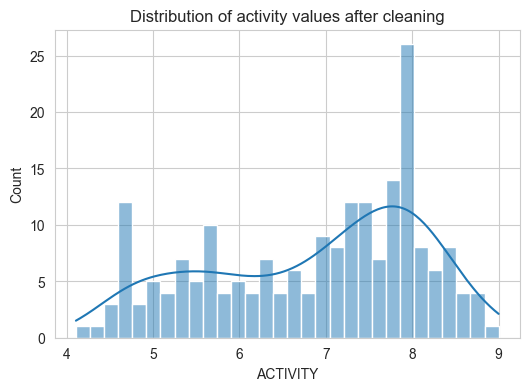

In [166]:
plt.figure(figsize=(6,4))
sns.histplot(df[ACTIVITY_COL], kde=True, bins=30)
plt.xlabel(ACTIVITY_COL)
plt.title("Distribution of activity values after cleaning")
plt.show()


In [167]:
mols = [Chem.MolFromSmiles(s) for s in df["SMILES_canonical"]]
df["mol"] = mols
assert all(m is not None for m in mols), "Unexpected parsing failure after cleaning"
df

,SMILES_canonical,ACTIVITY,canonical_smiles,mol
0,C#CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,8.455932,C#CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,<rdkit.Chem.rdchem.Mol object at 0x00000247D9D...
1,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,5.589584,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,<rdkit.Chem.rdchem.Mol object at 0x00000247D9D...
2,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,5.589584,C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-...,<rdkit.Chem.rdchem.Mol object at 0x00000247D9D...
3,C=CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,8.397940,C=CCn1c(C)nc2c(c(C(N)=O)c(N)n2-c2c(C)ccc(O)c2C...,<rdkit.Chem.rdchem.Mol object at 0x00000247D9D...
4,CC(C)(C)NS(=O)(=O)c1cncc(-c2ccn3nc(N)nc3c2)c1,5.000000,CC(C)(C)NS(=O)(=O)c1cncc(-c2ccn3nc(N)nc3c2)c1,<rdkit.Chem.rdchem.Mol object at 0x00000247D9D...
...,...,...,...,...
199,O=C(O[C@@H]1Cc2c(O)cc(O)cc2O[C@H]1c1cc(O)c(O)c...,6.798603,O=C(O[C@@H]1Cc2c(O)cc(O)cc2O[C@H]1c1cc(O)c(O)c...,<rdkit.Chem.rdchem.Mol object at 0x00000248502...
200,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,4.107905,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,<rdkit.Chem.rdchem.Mol object at 0x00000248502...
201,O=c1cc(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,5.823909,O=c1cc(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,<rdkit.Chem.rdchem.Mol object at 0x00000248502...
202,Oc1cccc(Nc2ccnc3cc(-c4ccncc4)ccc23)c1,6.315029,Oc1cccc(Nc2ccnc3cc(-c4ccncc4)ccc23)c1,<rdkit.Chem.rdchem.Mol object at 0x00000248502...


**Feature Extractions**

- rdkit Descriptors
- ECFP4
- ChemBERTA
- MolFormer

In [168]:
# --- 3a. Physicochemical descriptors ---
descriptor_names = [name for name, _ in Descriptors._descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

desc_rows = []
for m in df["mol"]:
    try:
        desc_rows.append(calculator.CalcDescriptors(m))
    except Exception:
        desc_rows.append([np.nan] * len(descriptor_names))

desc_df = pd.DataFrame(desc_rows, columns=descriptor_names)

# Drop descriptor columns that are constant or all-NaN (uninformative / break scaling)
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.dropna(axis=1, how="any")
desc_df = desc_df.loc[:, desc_df.std() > 0]

print(f"Descriptor matrix shape: {desc_df.shape}")
feat_dir = f"{OUTPUT_DIR}/Features"
os.makedirs(feat_dir, exist_ok = True)

save_desc = pd.concat(
    [df[[SMILES_COL, ACTIVITY_COL]].reset_index(drop=True), desc_df.reset_index(drop=True)],
    axis=1
)
save_desc.to_csv(os.path.join(feat_dir, "descriptors.csv"), index=False)
desc_df.head()


Descriptor matrix shape: (204, 172)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,...,fr_aryl_methyl,fr_benzene,fr_bicyclic,fr_ester,fr_ether,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_methoxy,fr_morpholine,fr_nitrile,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_urea
0,12.999516,12.999516,0.001065,-0.845630,0.599319,10.888889,365.393,346.241,365.148789,138,0.264288,-0.507605,0.507605,0.264288,1.333333,2.000000,2.592593,16.255491,10.080363,2.267032,-2.153503,2.340046,-2.250845,6.103232,0.100228,...,2,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0
1,13.208982,13.208982,0.202184,-1.027272,0.376271,14.756757,499.619,466.355,499.269573,192,0.277974,-0.385753,0.385753,0.277974,1.081081,1.810811,2.486486,16.281451,9.979861,2.204469,-2.336407,2.251304,-2.439808,5.771360,0.078553,...,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,13.181204,13.181204,0.242184,-1.138383,0.373518,14.756757,500.607,468.351,500.264822,192,0.278022,-0.384141,0.384141,0.278022,1.081081,1.810811,2.486486,16.282296,10.052518,2.216374,-2.336405,2.233567,-2.439808,5.767395,0.073765,...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
3,13.047294,13.047294,0.008938,-0.819801,0.604301,11.074074,367.409,346.241,367.164440,140,0.263722,-0.507605,0.507605,0.263722,1.333333,2.000000,2.592593,16.255491,10.080362,2.266545,-2.154245,2.340196,-2.249311,6.103209,0.100227,...,2,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0
4,12.452949,12.452949,0.107203,-3.652545,0.741481,12.625000,346.416,328.272,346.121195,126,0.242097,-0.366476,0.366476,0.242097,1.166667,1.916667,2.625000,32.233273,10.111204,2.222810,-2.199321,2.227622,-2.400186,7.891565,0.491099,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0


In [169]:
# --- 3b. Morgan fingerprints ---
N_BITS = 1024
RADIUS = 2

def get_morgan_fp(mol, radius=RADIUS, n_bits=N_BITS):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_array = np.array([get_morgan_fp(m) for m in df["mol"]])
fp_df = pd.DataFrame(fp_array, columns=[f"FP_{i}" for i in range(N_BITS)])
print(f"Fingerprint matrix shape: {fp_df.shape}")
save_fp = pd.concat(
    [df[[SMILES_COL, ACTIVITY_COL]].reset_index(drop=True), fp_df.reset_index(drop=True)],
    axis=1
)
save_fp.to_csv(os.path.join(feat_dir, "fingerprints.csv"), index=False)
fp_df.head()


Fingerprint matrix shape: (204, 1024)


[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerator
[20:32:40] DEPRECATION WARNING: please use MorganGenerat

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,FP_10,FP_11,FP_12,FP_13,FP_14,FP_15,FP_16,FP_17,FP_18,FP_19,FP_20,FP_21,FP_22,FP_23,FP_24,...,FP_999,FP_1000,FP_1001,FP_1002,FP_1003,FP_1004,FP_1005,FP_1006,FP_1007,FP_1008,FP_1009,FP_1010,FP_1011,FP_1012,FP_1013,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [170]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
model = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
model.eval()

embeddings = []
with torch.no_grad():
    for smi in df[SMILES_COL]:
        inputs = tokenizer(smi, return_tensors="pt")
        out = model(**inputs)
        emb = out.last_hidden_state.mean(dim=1).squeeze().numpy()  # mean pooling
        embeddings.append(emb)

embeddings = np.array(embeddings)


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [171]:
chemberta_df = pd.DataFrame(embeddings, columns = [f"chemb_{i}" for i in range(embeddings.shape[1])])
save_chemberta = pd.concat(
    [df[[SMILES_COL, ACTIVITY_COL]].reset_index(drop=True), chemberta_df.reset_index(drop=True)],
    axis=1
)
save_chemberta.to_csv(os.path.join(feat_dir, "chemberta.csv"), index=False)

chemberta_df.head(5)


,chemb_0,chemb_1,chemb_2,chemb_3,chemb_4,chemb_5,chemb_6,chemb_7,chemb_8,chemb_9,chemb_10,chemb_11,chemb_12,chemb_13,chemb_14,chemb_15,chemb_16,chemb_17,chemb_18,chemb_19,chemb_20,chemb_21,chemb_22,chemb_23,chemb_24,...,chemb_359,chemb_360,chemb_361,chemb_362,chemb_363,chemb_364,chemb_365,chemb_366,chemb_367,chemb_368,chemb_369,chemb_370,chemb_371,chemb_372,chemb_373,chemb_374,chemb_375,chemb_376,chemb_377,chemb_378,chemb_379,chemb_380,chemb_381,chemb_382,chemb_383
0,0.094215,0.100681,-0.051792,0.147716,-0.044016,0.077743,-0.141372,0.087758,-0.002791,0.065738,0.102621,0.109534,0.060728,0.066309,0.052363,-0.121991,-0.016072,-0.073296,-0.089531,-0.045462,0.052592,0.157658,0.012853,-0.079357,0.107388,...,0.134995,0.001549,-0.034768,0.037789,-0.030751,-0.104463,0.015271,-0.095401,-0.099729,0.055210,0.107059,0.085341,0.097968,0.105478,0.101023,-0.075019,-0.038049,0.144650,-0.018074,0.079944,-0.155871,0.097842,0.160039,0.006564,-0.048037
1,0.014978,0.045296,-0.066870,0.100494,0.077743,0.126234,0.045224,0.149991,-0.006915,0.139577,0.166428,0.152399,0.083304,0.098079,-0.049426,-0.096893,-0.034189,0.017452,-0.098730,0.210527,0.118471,0.124552,-0.013652,0.046864,0.080212,...,0.102132,0.030988,0.062729,0.122501,0.009146,-0.086236,0.126644,-0.121423,0.031917,0.126562,0.049571,0.017420,0.071102,0.048953,0.166740,-0.126558,-0.035920,-0.040398,-0.012002,0.009716,-0.203564,0.120869,0.092189,0.059103,-0.028432
2,0.016384,0.039879,-0.045037,0.110840,0.055052,0.137359,0.052013,0.121585,-0.010948,0.144931,0.149581,0.192538,0.094740,0.101917,-0.052587,-0.084655,-0.041696,-0.018325,-0.074112,0.185129,0.099082,0.130924,-0.020082,0.038428,0.072971,...,0.109984,0.025324,0.064036,0.134298,0.023337,-0.120918,0.127452,-0.111045,0.012604,0.107916,0.054495,0.007574,0.076552,0.070602,0.175354,-0.108522,-0.042213,-0.027383,-0.021127,0.024878,-0.212185,0.115514,0.137471,0.050140,0.007865
3,0.105697,0.082126,-0.058978,0.169308,-0.043061,0.092918,-0.142175,0.080560,-0.010720,0.088125,0.087014,0.093434,0.055985,0.092898,0.068485,-0.114287,-0.033539,-0.061393,-0.092982,-0.051685,0.088169,0.187243,0.016702,-0.093042,0.082179,...,0.140823,-0.013254,-0.035006,0.026515,-0.050954,-0.104779,0.016164,-0.089386,-0.078243,0.074421,0.073513,0.073109,0.102391,0.055627,0.086259,-0.063712,-0.037865,0.150173,0.001120,0.086843,-0.154356,0.105456,0.182970,0.029125,-0.098240
4,-0.061592,-0.055104,0.082087,0.037855,0.091577,0.112286,0.054806,0.228559,-0.033671,0.154623,0.021693,0.186336,0.085938,-0.158936,0.013498,-0.050559,0.003825,0.113168,0.002445,0.216329,0.074195,0.064811,-0.002812,0.029012,0.133956,...,0.117441,0.035649,0.052843,0.146764,-0.041632,-0.190492,0.248307,-0.176923,0.113920,0.100013,-0.030693,0.199963,0.037532,0.261345,0.084216,-0.149158,0.069913,0.077827,-0.086679,-0.002817,-0.142989,0.115307,-0.033226,0.051899,-0.074970


In [172]:
tokenizer = AutoTokenizer.from_pretrained(
    "ibm/MoLFormer-XL-both-10pct", trust_remote_code=True
)
model = AutoModel.from_pretrained(
    "ibm/MoLFormer-XL-both-10pct", trust_remote_code=True
)
model.eval()


Loading weights:   0%|          | 0/207 [00:00<?, ?it/s]

MolformerModel LOAD REPORT from: ibm/MoLFormer-XL-both-10pct
Key                                | Status     |  | 
-----------------------------------+------------+--+-
lm_head.decoder.weight             | UNEXPECTED |  | 
lm_head.transform.LayerNorm.weight | UNEXPECTED |  | 
lm_head.transform.dense.bias       | UNEXPECTED |  | 
lm_head.transform.dense.weight     | UNEXPECTED |  | 
lm_head.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MolformerModel(
  (embeddings): MolformerEmbeddings(
    (word_embeddings): Embedding(2362, 768, padding_idx=2)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): MolformerEncoder(
    (layer): ModuleList(
      (0-11): 12 x MolformerLayer(
        (attention): MolformerAttention(
          (self): MolformerSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (rotary_embeddings): MolformerRotaryEmbedding()
            (feature_map): MolformerFeatureMap(
              (kernel): ReLU()
            )
          )
          (output): MolformerSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (in

In [173]:
embeddings = []

with torch.no_grad():
    for smi in df[SMILES_COL]:
        inputs = tokenizer(smi, return_tensors="pt", padding=True, truncation=True)
        out = model(**inputs)
        # MoLFormer exposes a pooled [CLS]-like output directly
        emb = out.pooler_output.squeeze().numpy()
        embeddings.append(emb)

embeddings = np.array(embeddings)
print(embeddings.shape)  # (n_molecules, 768)

molformer_df = pd.DataFrame(embeddings, columns=[f"molformer_{i}" for i in range(embeddings.shape[1])])
save_molformer = pd.concat(
    [df[[SMILES_COL, ACTIVITY_COL]].reset_index(drop=True), molformer_df.reset_index(drop=True)],
    axis=1
)
save_molformer.to_csv(os.path.join(feat_dir, "molformer.csv"), index=False)

(204, 768)


In [174]:
y = df[ACTIVITY_COL].values


**Train-Test Split**

In [175]:
idx_train, idx_test = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

y_train, y_test = y[idx_train], y[idx_test]
print(f"Train: {len(idx_train)}, Test: {len(idx_test)}")


Train: 163, Test: 41


In [176]:
def scale_split(X_df, idx_train, idx_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_df.loc[idx_train])
    X_test = scaler.transform(X_df.loc[idx_test])
    return X_train, X_test, scaler

Xchemb_train, Xchemb_test, chemb_scaler = scale_split(chemberta_df, idx_train, idx_test)
Xd_train, Xd_test, desc_scaler = scale_split(desc_df, idx_train, idx_test)
Xf_train, Xf_test, fp_scaler = scale_split(fp_df, idx_train, idx_test)
Xmolf_train, Xmolf_test, molf_scaler = scale_split(molformer_df, idx_train,idx_test)




**Model Building**

Builds 4(Features) x 9(ML algorithms) = 36 Models

In [177]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


def get_model_dict():
    return {
        "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
        "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "Lasso": Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000),
        "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
        "SVR_RBF": SVR(kernel="rbf", C=10.0, epsilon=0.1),
        "KNN": KNeighborsRegressor(n_neighbors=5, weights="distance"),
        "GaussianProcess": GaussianProcessRegressor(
            kernel=ConstantKernel() * RBF(), alpha=1e-2, normalize_y=True, random_state=RANDOM_STATE
        ),
        "PLS": PLSRegression(n_components=10),  # overridden per-call where X shape is known
    }

def train_eval(X_train, y_train, X_test, y_test, sample_weight=None, label=""):
    results = {}
    models = get_model_dict()
    # fix PLS n_components to this call's actual data shape
    models["PLS"] = PLSRegression(n_components=min(10, X_train.shape[1], X_train.shape[0] - 1))

    for name, model in models.items():
        fit_kwargs = {}
        if sample_weight is not None and "sample_weight" in model.fit.__code__.co_varnames:
            fit_kwargs["sample_weight"] = sample_weight

        model.fit(X_train, y_train, **fit_kwargs)

        train_preds = np.ravel(model.predict(X_train))   # <-- ADDED
        preds = np.ravel(model.predict(X_test))

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        results[name] = {
            "model": model,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_preds": train_preds,   # <-- ADDED
            "preds": preds,
        }
        print(f"[{label}] {name}: RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")

    return results


print("\n=== Chemberta-based models (baseline) ===")
chemb_results_base = train_eval(Xchemb_train, y_train, Xchemb_test, y_test, label="Chemberta Embeddings")
print("\n=== Descriptor-based models (baseline) ===")
desc_results_base = train_eval(Xd_train, y_train, Xd_test, y_test, label="Descriptors")

print("\n=== Fingerprint-based models (baseline) ===")
fp_results_base = train_eval(Xf_train, y_train, Xf_test, y_test, label="Fingerprints")

print("\n=== Molformer-based models (baseline) ===")
molf_results_base = train_eval(Xmolf_train, y_train, Xmolf_test, y_test, label="Molformer Embeddings")


=== Chemberta-based models (baseline) ===
[Chemberta Embeddings] RandomForest: RMSE=0.704  MAE=0.540  R2=0.642
[Chemberta Embeddings] GradientBoosting: RMSE=0.723  MAE=0.510  R2=0.622
[Chemberta Embeddings] Ridge: RMSE=1.229  MAE=0.875  R2=-0.091
[Chemberta Embeddings] Lasso: RMSE=0.870  MAE=0.599  R2=0.453
[Chemberta Embeddings] ElasticNet: RMSE=0.905  MAE=0.648  R2=0.409
[Chemberta Embeddings] SVR_RBF: RMSE=0.719  MAE=0.518  R2=0.627
[Chemberta Embeddings] KNN: RMSE=0.776  MAE=0.560  R2=0.565
[Chemberta Embeddings] GaussianProcess: RMSE=0.785  MAE=0.550  R2=0.554
[Chemberta Embeddings] PLS: RMSE=0.690  MAE=0.530  R2=0.656

=== Descriptor-based models (baseline) ===
[Descriptors] RandomForest: RMSE=0.575  MAE=0.411  R2=0.761
[Descriptors] GradientBoosting: RMSE=0.572  MAE=0.424  R2=0.764
[Descriptors] Ridge: RMSE=0.750  MAE=0.556  R2=0.594
[Descriptors] Lasso: RMSE=0.740  MAE=0.577  R2=0.604
[Descriptors] ElasticNet: RMSE=0.740  MAE=0.561  R2=0.604
[Descriptors] SVR_RBF: RMSE=0.732  

In [178]:
# Store train-set predictions for cliff pair analysis
for results_dict, X_train, X_test in [
    (desc_results_base, Xd_train, Xd_test),
    (fp_results_base,   Xf_train, Xf_test),
    (chemb_results_base, Xchemb_train, Xchemb_test),
    (molf_results_base, Xmolf_train, Xmolf_test)
]:
    for name, r in results_dict.items():
        r["train_preds"] = r["model"].predict(X_train)

**Shortlisting top 20 models based on test RMSE for k-fold predictions**

In [179]:
def error_contribution(results_dict, label, y, idx_train, idx_test,
                              ):
    y_train = y[idx_train]
    y_test  = y[idx_test]
    rows = []

    for model_name, r in results_dict.items():
        train_preds = np.ravel(r["train_preds"])
        test_preds  = np.ravel(r["preds"])

        for split_name, actual, preds in [
            ("Train", y_train, train_preds),
            ("Test",  y_test,  test_preds),
        ]:
            abs_err = np.abs(actual - preds)
            sq_err  = (actual - preds) ** 2

            overall_rmse = np.sqrt(sq_err.mean())
            overall_mae  = abs_err.mean()

            n_total = len(actual)
            
            rows.append({
                "features": label,
                "model": model_name,
                "split": split_name,
                "n_total": n_total,
                "overall_rmse": overall_rmse,
                "overall_mae": overall_mae,
                })

    return pd.DataFrame(rows)

results_map = {
    "Chemberta Embeddings": chemb_results_base,
    "Descriptors":          desc_results_base,
    "Fingerprints":         fp_results_base,
    "Molformer Embeddings": molf_results_base,
}

error_contrib = pd.concat(
    [
        error_contribution(r, label, y, idx_train, idx_test)
        for label, r in results_map.items()
    ],
    ignore_index=True,
)

error_contrib.sort_values(["split", "features", "model"]).reset_index(drop=True)

,features,model,split,n_total,overall_rmse,overall_mae
0,Chemberta Embeddings,ElasticNet,Test,41,0.904601,0.648376
1,Chemberta Embeddings,GaussianProcess,Test,41,0.785495,0.549836
2,Chemberta Embeddings,GradientBoosting,Test,41,0.722759,0.510234
3,Chemberta Embeddings,KNN,Test,41,0.775609,0.559806
4,Chemberta Embeddings,Lasso,Test,41,0.870117,0.599271
...,...,...,...,...,...,...
67,Molformer Embeddings,Lasso,Train,163,0.228830,0.183134
68,Molformer Embeddings,PLS,Train,163,0.257648,0.200412
69,Molformer Embeddings,RandomForest,Train,163,0.309866,0.246496
70,Molformer Embeddings,Ridge,Train,163,0.011142,0.008728


In [180]:
perf = error_contrib.pivot_table(
    index=["features", "model"],
    columns="split",
    values=["overall_rmse", "overall_mae"]
)

if perf.empty:
    print("error_contrib is empty — no models to shortlist.")
    top20_test_rmse = pd.DataFrame(columns=["features", "model", "train_rmse", "test_rmse"])
    top10_least_overfit = pd.DataFrame(columns=["features", "model", "train_rmse", "test_rmse", "overfit_gap"])
    top20_full = pd.DataFrame()
    top10_full = pd.DataFrame()
else:
    perf.columns = [f"{metric}_{split.lower()}" for metric, split in perf.columns]
    perf = perf.reset_index().rename(columns={
        "overall_rmse_train": "train_rmse",
        "overall_rmse_test":  "test_rmse",
        "overall_mae_train":  "train_mae",
        "overall_mae_test":   "test_mae",
    })

    
    perf = perf.dropna(subset=["train_rmse", "test_rmse"])

    if perf.empty:
        print("No model has both Train and Test RMSE — nothing to shortlist.")
        top20_test_rmse = pd.DataFrame(columns=["features", "model", "train_rmse", "test_rmse"])
        top10_least_overfit = pd.DataFrame(columns=["features", "model", "train_rmse", "test_rmse", "overfit_gap"])
        top20_full = pd.DataFrame()
        top10_full = pd.DataFrame()
    else:
        TRAIN_RMSE_POOR_QUANTILE = 0.9
        train_rmse_poor_cutoff = perf["train_rmse"].quantile(TRAIN_RMSE_POOR_QUANTILE)
        well_trained = perf[perf["train_rmse"] <= train_rmse_poor_cutoff].copy()

        top20_test_rmse = well_trained.sort_values("test_rmse").head(20).reset_index(drop=True)

        top20_keys = top20_test_rmse[["features", "model"]].drop_duplicates()
        top20_full = error_contrib.merge(top20_keys, on=["features", "model"], how="inner")

        top20_full = top20_full.merge(
            top20_test_rmse[["features", "model", "train_rmse", "test_rmse"]],
            on=["features", "model"], how="left"
        )


if not top20_full.empty:
    top20_full.to_csv(f"{OUTPUT_DIR}/top20_test_rmse_models_full.csv", index=False)


print("Top 20 by test RMSE (train RMSE excluded if in worst 10% overall):")
print(top20_test_rmse[["features", "model", "train_rmse", "test_rmse"]] if not top20_test_rmse.empty else "  (none)")



Top 20 by test RMSE (train RMSE excluded if in worst 10% overall):
                features             model  train_rmse  test_rmse
0            Descriptors  GradientBoosting    0.019230   0.571911
1            Descriptors      RandomForest    0.275070   0.575335
2           Fingerprints      RandomForest    0.264761   0.584176
3           Fingerprints  GradientBoosting    0.090798   0.584544
4   Molformer Embeddings           SVR_RBF    0.096373   0.629692
5   Molformer Embeddings             Lasso    0.228830   0.647432
6   Molformer Embeddings               PLS    0.257648   0.651376
7   Molformer Embeddings  GradientBoosting    0.000510   0.658830
8           Fingerprints               PLS    0.084491   0.669912
9   Molformer Embeddings      RandomForest    0.309866   0.676022
10          Fingerprints             Lasso    0.119401   0.687311
11          Fingerprints        ElasticNet    0.088381   0.694269
12  Molformer Embeddings        ElasticNet    0.150862   0.695913
13  Chemb

**K-Fold Model Building**

In [181]:
from sklearn.model_selection import KFold

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
idx_train_arr = np.array(idx_train)

feature_dfs = {
    "Chemberta Embeddings": chemberta_df,
    "Descriptors":          desc_df,
    "Fingerprints":         fp_df,
    "Molformer Embeddings": molformer_df,
}

def generate_oof_predictions(top_models_df, feature_dfs, y, idx_train_arr, kf):
    oof_results_map = {}
    for _, row in top_models_df.iterrows():
        label = row["features"]
        model_name = row["model"]
        X_df = feature_dfs[label]
        oof_preds = np.full(len(idx_train_arr), np.nan)

        for fold_train_pos, fold_val_pos in kf.split(idx_train_arr):
            fold_train_idx = idx_train_arr[fold_train_pos]
            fold_val_idx   = idx_train_arr[fold_val_pos]

            scaler = StandardScaler()
            X_fold_train = scaler.fit_transform(X_df.loc[fold_train_idx])
            X_fold_val   = scaler.transform(X_df.loc[fold_val_idx])
            y_fold_train = y[fold_train_idx]

            models = get_model_dict()
            if model_name == "PLS":
                models["PLS"] = PLSRegression(
                    n_components=min(10, X_fold_train.shape[1], X_fold_train.shape[0] - 1)
                )
            model = models[model_name]
            model.fit(X_fold_train, y_fold_train)
            oof_preds[fold_val_pos] = np.ravel(model.predict(X_fold_val))

        oof_results_map.setdefault(label, {})[model_name] = {"preds": oof_preds}
        print(f"OOF done: {label} / {model_name}")

    return oof_results_map

oof_results_map = generate_oof_predictions(top20_keys, feature_dfs, y, idx_train_arr, kf)

OOF done: Descriptors / GradientBoosting
OOF done: Descriptors / RandomForest
OOF done: Fingerprints / RandomForest
OOF done: Fingerprints / GradientBoosting
OOF done: Molformer Embeddings / SVR_RBF
OOF done: Molformer Embeddings / Lasso
OOF done: Molformer Embeddings / PLS
OOF done: Molformer Embeddings / GradientBoosting
OOF done: Fingerprints / PLS
OOF done: Molformer Embeddings / RandomForest
OOF done: Fingerprints / Lasso
OOF done: Fingerprints / ElasticNet
OOF done: Molformer Embeddings / ElasticNet
OOF done: Chemberta Embeddings / RandomForest
OOF done: Fingerprints / Ridge
OOF done: Fingerprints / SVR_RBF
OOF done: Chemberta Embeddings / SVR_RBF
OOF done: Chemberta Embeddings / GradientBoosting
OOF done: Descriptors / SVR_RBF
OOF done: Descriptors / Ridge


In [182]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

cv_results = []

for feature, models in oof_results_map.items():
    for model_name, data in models.items():
        preds = data["preds"]

        cv_results.append({
            "features": feature,
            "model": model_name,
            "CV R²": r2_score(y[idx_train], preds),
            "CV RMSE": np.sqrt(mean_squared_error(y[idx_train], preds)),
            "CV MAE": mean_absolute_error(y[idx_train], preds),
        })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

                features             model     CV R²   CV RMSE    CV MAE
0            Descriptors  GradientBoosting  0.634593  0.754776  0.545368
1            Descriptors      RandomForest  0.621497  0.768182  0.563604
2            Descriptors           SVR_RBF  0.644385  0.744594  0.552706
3            Descriptors             Ridge  0.338639  1.015427  0.729237
4           Fingerprints      RandomForest  0.687988  0.697453  0.517449
5           Fingerprints  GradientBoosting  0.681848  0.704282  0.524093
6           Fingerprints               PLS  0.661652  0.726292  0.551323
7           Fingerprints             Lasso  0.619602  0.770102  0.560600
8           Fingerprints        ElasticNet  0.642071  0.747013  0.532927
9           Fingerprints             Ridge  0.648351  0.740431  0.564909
10          Fingerprints           SVR_RBF  0.585353  0.804024  0.612833
11  Molformer Embeddings           SVR_RBF  0.661191  0.726786  0.568615
12  Molformer Embeddings             Lasso  0.53549

**Identifying Overfit Gap**

To identify the models that are overfitted on the training data leading to poor predictions on test data, overfit gap is calcuated:
- (test_RMSE - train_RMSE)x100

The lower the value, higher probability that the models are not overfit.
Choosing top 10 models with the lowest overfit gaps based on k-fold predictions

*Important to ensure that the lower values are not due to poor training metrics*

In [183]:
from sklearn.metrics import mean_squared_error

train_rmse_rows = []

for feature, models in results_map.items():
    for model_name, r in models.items():
        train_preds = r["train_preds"]  # in-sample predictions, full training fit
        train_rmse = np.sqrt(mean_squared_error(y[idx_train], train_preds))
        train_rmse_rows.append({
            "features": feature,
            "model": model_name,
            "Train RMSE (in-sample)": train_rmse,
        })

train_rmse_df = pd.DataFrame(train_rmse_rows)

# ---- merge with your existing cv_results_df ----
overfit_df = cv_results_df.merge(train_rmse_df, on=["features", "model"], how="left")

overfit_df["overfit_gap_cv"] = (
    (overfit_df["CV RMSE"] - overfit_df["Train RMSE (in-sample)"]) * 100
)

overfit_df = overfit_df.sort_values("overfit_gap_cv").reset_index(drop=True)
overfit_df.to_csv(os.path.join(OUTPUT_DIR, "overfit_gap_cv.csv"), index=False)

print(overfit_df[["features", "model", "Train RMSE (in-sample)", "CV RMSE", "overfit_gap_cv"]])

                features             model  Train RMSE (in-sample)   CV RMSE  \
0           Fingerprints      RandomForest                0.264761  0.697453   
1            Descriptors      RandomForest                0.275070  0.768182   
2   Molformer Embeddings      RandomForest                0.309866  0.803665   
3   Chemberta Embeddings      RandomForest                0.298047  0.815816   
4            Descriptors           SVR_RBF                0.205136  0.744594   
5   Chemberta Embeddings           SVR_RBF                0.137521  0.714911   
6           Fingerprints  GradientBoosting                0.090798  0.704282   
7   Molformer Embeddings             Lasso                0.228830  0.850993   
8   Molformer Embeddings           SVR_RBF                0.096373  0.726786   
9           Fingerprints               PLS                0.084491  0.726292   
10          Fingerprints             Lasso                0.119401  0.770102   
11          Fingerprints        ElasticN

In [184]:
top10_keys = overfit_df.head(10)[["features", "model"]].drop_duplicates()
model_labels = [f"{r.features}__{r.model}" for r in top10_keys.itertuples()]



This module calculates the following metrics to help shortlist models for an ensemble:

- **Double Fault**: Measures how often two models make incorrect predictions simultaneously, where both prediction errors exceed a specified error threshold.
- **Disagreement**: Measures how often two models produce different prediction outcomes, or when one model's prediction error exceeds the threshold while the other's does not.
- **Q-Statistic**: Measures the complementarity between two models by quantifying the relationship between their prediction correctness, helping identify models that make different types of errors.

In [185]:
import itertools

ERROR_THRESHOLD = 0.5  # "correct" if abs_error < this

PAIRWISE_COLS = [
    "model_a", "model_b", "n_total", "n11_both_correct", "n00_both_wrong",
    "n10_a_correct_b_wrong", "n01_a_wrong_b_correct", "q_statistic",
    "disagreement", "double_fault", "pct_a_rescues_b", "pct_b_rescues_a",
    "passes_double_fault_filter",
]

def pairwise_diversity_table(wide_df, model_labels):
    # Guard: need at least 2 models to form any pair, and at least 1 row
    # to compare them on. Without this, itertools.combinations produces
    # zero rows, pd.DataFrame(rows) yields a columnless empty frame, and
    # df["double_fault"].quantile(...) below raises a KeyError.
    if wide_df is None or wide_df.empty or len(model_labels) < 2:
        print(f"pairwise_diversity_table: skipping — "
              f"{'no rows' if wide_df is None or wide_df.empty else 'fewer than 2 models'}.")
        return pd.DataFrame(columns=PAIRWISE_COLS)

    rows = []
    for m_a, m_b in itertools.combinations(model_labels, 2):
        col_a, col_b = f"correct_{m_a}", f"correct_{m_b}"
        if col_a not in wide_df.columns or col_b not in wide_df.columns:
            # Can happen if a model had zero rows in this particular slice
            # (e.g. cliff-only) and its pivoted column never got created.
            print(f"  skipping pair ({m_a}, {m_b}) — missing column in this slice.")
            continue

        a = wide_df[col_a].values
        b = wide_df[col_b].values

        n11 = int(((a == 1) & (b == 1)).sum())
        n00 = int(((a == 0) & (b == 0)).sum())
        n10 = int(((a == 1) & (b == 0)).sum())
        n01 = int(((a == 0) & (b == 1)).sum())
        n_total = n11 + n00 + n10 + n01

        denom_q = (n11 * n00 + n01 * n10)
        q_stat = ((n11 * n00 - n01 * n10) / denom_q) if denom_q != 0 else np.nan

        disagreement = (n10 + n01) / n_total if n_total else np.nan
        double_fault = n00 / n_total if n_total else np.nan
        pct_a_rescues_b = 100 * n10 / n_total if n_total else np.nan
        pct_b_rescues_a = 100 * n01 / n_total if n_total else np.nan

        rows.append({
            "model_a": m_a, "model_b": m_b, "n_total": n_total,
            "n11_both_correct": n11, "n00_both_wrong": n00,
            "n10_a_correct_b_wrong": n10, "n01_a_wrong_b_correct": n01,
            "q_statistic": q_stat, "disagreement": disagreement,
            "double_fault": double_fault,
            "pct_a_rescues_b": pct_a_rescues_b, "pct_b_rescues_a": pct_b_rescues_a,
        })

    if not rows:
        print("pairwise_diversity_table: no valid pairs after column checks.")
        return pd.DataFrame(columns=PAIRWISE_COLS)

    df = pd.DataFrame(rows)

    double_fault_cutoff = df["double_fault"].quantile(0.75)
    df["passes_double_fault_filter"] = (
        df["double_fault"] <= double_fault_cutoff if not df["double_fault"].isna().all() else True
    )

    df = df.sort_values(
        by=["passes_double_fault_filter", "disagreement", "q_statistic"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return df


def long_to_wide(long_df):
    # Guard: empty long_df means pivot_table has nothing to pivot on —
    # rather than let it raise or silently produce a malformed frame,
    # return a clean empty frame with the expected index columns.
    if long_df is None or long_df.empty:
        print("long_to_wide: input is empty — returning empty wide frame.")
        return pd.DataFrame(columns=["SMILES"])

    correct_wide = long_df.pivot_table(index=["SMILES"],
                                        columns="model_label", values="correct")
    correct_wide.columns = [f"correct_{c}" for c in correct_wide.columns]

    err_wide = long_df.pivot_table(index=["SMILES"],
                                    columns="model_label", values="abs_error")
    err_wide.columns = [f"err_{c}" for c in err_wide.columns]

    wide = correct_wide.join(err_wide).reset_index()
    return wide


def build_model_prediction_long(top_models_df, results_map, y, idx_test,
                                 test_smiles, threshold=ERROR_THRESHOLD):
    # Guard: no shortlisted models means nothing to build.
    if top_models_df is None or top_models_df.empty:
        print("build_model_prediction_long: no models in top_models_df — returning empty long_df.")
        return pd.DataFrame(columns=["SMILES", "model_label",
                                      "actual", "pred", "abs_error", "correct"])

    # Guard: no molecules in this split (e.g. idx_test empty).
    if len(test_smiles) == 0:
        print("build_model_prediction_long: no molecules in this split — returning empty long_df.")
        return pd.DataFrame(columns=["SMILES", "model_label",
                                      "actual", "pred", "abs_error", "correct"])

    y_test = y[idx_test]
    rows = []
    for _, row in top_models_df.iterrows():
        label = row["features"]
        model_name = row["model"]
        model_label = f"{label}__{model_name}"

        r = results_map[label][model_name]
        preds = np.ravel(r["preds"])
        abs_err = np.abs(y_test - preds)
        correct = (abs_err < threshold).astype(int)

        for smi, actual, pred, err, corr in zip(
            test_smiles, y_test, preds, abs_err, correct
        ):
            rows.append({
                "SMILES": smi, "model_label": model_label,
                "actual": actual, "pred": pred, "abs_error": err, "correct": corr,
            })

    return pd.DataFrame(rows)

In [186]:

OOF_WIDE_COLS = ["SMILES", "is_cliff"]

if len(idx_train_arr) == 0:
    print("idx_train_arr is empty — skipping OOF cliff analysis entirely.")
    train_smiles_arr = np.array([])
  
else:
    train_smiles_arr = df.loc[idx_train_arr]["SMILES_canonical"].values

# top10_keys / model_labels may already be empty from the shortlist step
if top10_keys.empty or len(model_labels) < 2 or len(train_smiles_arr) == 0:
    print("Skipping OOF diversity analysis — missing shortlisted models, "
          "fewer than 2 models, or no training molecules to evaluate on.")
    long_df_oof = pd.DataFrame(columns=["SMILES", "is_cliff", "model_label",
                                         "actual", "pred", "abs_error", "correct"])
    wide_all_oof = pd.DataFrame(columns=OOF_WIDE_COLS)
    pairwise_all_oof = pd.DataFrame(columns=PAIRWISE_COLS)
    wide_cliff_oof = pd.DataFrame(columns=OOF_WIDE_COLS)
    pairwise_cliff_oof = pd.DataFrame(columns=PAIRWISE_COLS)
else:
    long_df_oof = build_model_prediction_long(
        top10_keys, oof_results_map, y, idx_train_arr, train_smiles_arr
    )

    # OOF, all molecules
    wide_all_oof = long_to_wide(long_df_oof)
    pairwise_all_oof = pairwise_diversity_table(wide_all_oof, model_labels)


# Always write files (even if empty) so downstream steps that expect these
# paths to exist don't fail with FileNotFoundError — but log when they're empty.
wide_all_oof.to_csv(os.path.join(OUTPUT_DIR, "wide_matrix_all_molecules_OOF.csv"), index=False)
pairwise_all_oof.to_csv(os.path.join(OUTPUT_DIR, "pairwise_diversity_all_molecules_OOF.csv"), index=False)


if wide_all_oof.empty:
    print("wide_matrix_all_molecules_OOF.csv written empty (no data).")


print("Top pairs (all molecules):")
if pairwise_all_oof.empty:
    print("  (no pairs to show)")
else:
    print(pairwise_all_oof.head(10)[["model_a", "model_b", "disagreement", "double_fault", "q_statistic"]])

Top pairs (all molecules):
                              model_a                         model_b  \
0  Molformer Embeddings__RandomForest     Molformer Embeddings__Lasso   
1                Descriptors__SVR_RBF     Molformer Embeddings__Lasso   
2           Descriptors__RandomForest     Molformer Embeddings__Lasso   
3  Molformer Embeddings__RandomForest  Fingerprints__GradientBoosting   
4         Molformer Embeddings__Lasso               Fingerprints__PLS   
5  Molformer Embeddings__RandomForest            Descriptors__SVR_RBF   
6  Molformer Embeddings__RandomForest               Fingerprints__PLS   
7  Chemberta Embeddings__RandomForest     Molformer Embeddings__Lasso   
8       Chemberta Embeddings__SVR_RBF     Molformer Embeddings__Lasso   
9          Fingerprints__RandomForest     Molformer Embeddings__Lasso   

   disagreement  double_fault  q_statistic  
0      0.411043      0.319018     0.342723  
1      0.404908      0.251534     0.397869  
2      0.380368      0.269939     

In [187]:
wide_all_oof.to_csv(os.path.join(OUTPUT_DIR, "wide_matrix_all_molecules_OOF.csv"), index=False)
pairwise_all_oof.to_csv(os.path.join(OUTPUT_DIR, "pairwise_diversity_all_molecules_OOF.csv"), index=False)



print("Top pairs (all molecules):")
print(pairwise_all_oof.head(10)[["model_a", "model_b", "disagreement", "double_fault", "q_statistic"]])

Top pairs (all molecules):
                              model_a                         model_b  \
0  Molformer Embeddings__RandomForest     Molformer Embeddings__Lasso   
1                Descriptors__SVR_RBF     Molformer Embeddings__Lasso   
2           Descriptors__RandomForest     Molformer Embeddings__Lasso   
3  Molformer Embeddings__RandomForest  Fingerprints__GradientBoosting   
4         Molformer Embeddings__Lasso               Fingerprints__PLS   
5  Molformer Embeddings__RandomForest            Descriptors__SVR_RBF   
6  Molformer Embeddings__RandomForest               Fingerprints__PLS   
7  Chemberta Embeddings__RandomForest     Molformer Embeddings__Lasso   
8       Chemberta Embeddings__SVR_RBF     Molformer Embeddings__Lasso   
9          Fingerprints__RandomForest     Molformer Embeddings__Lasso   

   disagreement  double_fault  q_statistic  
0      0.411043      0.319018     0.342723  
1      0.404908      0.251534     0.397869  
2      0.380368      0.269939     

Creating the intial n ensemble pairs

In [188]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Step 1: build a list of (name, [model_a, model_b]) pairs from each top-3 table ----
def pairs_from_table(pairwise_df, prefix, n=3):
    top_n = pairwise_df.head(n)
    pairs = []
    for i, row in top_n.iterrows():
        name = f"{prefix}_pair{i+1}"
        pairs.append((name, [row["model_a"], row["model_b"]]))
    return pairs

all_pairs = pairs_from_table(pairwise_all_oof, "all", n=4)


for name, members in all_pairs:
    print(name, "->", members)

all_pair1 -> ['Molformer Embeddings__RandomForest', 'Molformer Embeddings__Lasso']
all_pair2 -> ['Descriptors__SVR_RBF', 'Molformer Embeddings__Lasso']
all_pair3 -> ['Descriptors__RandomForest', 'Molformer Embeddings__Lasso']
all_pair4 -> ['Molformer Embeddings__RandomForest', 'Fingerprints__GradientBoosting']


In [189]:
# ---- Step 2: helpers to fetch member predictions and average them (simple mean of 2 models) ----
# ASSUMPTION: results_map[features][model_name] holds test preds under "preds" (as in your
# original code) and train preds under "train_preds". Adjust the keys below if different.
TRAIN_PRED_KEY = "train_preds"
TEST_PRED_KEY = "preds"

def ensemble_predict(model_labels_list, split, results_map, idx, y_full):
    preds_stack = []
    for label in model_labels_list:
        features, model_name = label.split("__", 1)
        r = results_map[features][model_name]
        key = TEST_PRED_KEY if split == "test" else TRAIN_PRED_KEY
        if key not in r:
            raise KeyError(
                f"'{key}' not found for {label}. Adjust TRAIN_PRED_KEY/TEST_PRED_KEY "
                f"to match how your results_map stores {split} predictions."
            )
        preds_stack.append(np.ravel(r[key]))
    preds_stack = np.vstack(preds_stack)
    ensemble_pred = preds_stack.mean(axis=0)
    y_true = y_full[idx]
    return ensemble_pred, y_true


def compute_stats(y_true, y_pred, threshold=ERROR_THRESHOLD):
    abs_err = np.abs(y_true - y_pred)
    stats = {
        "n": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "accuracy_at_thresh": float((abs_err < threshold).mean()),
    }
    return stats

In [190]:
for label, model_dict in oof_results_map.items():
    for model_name, r in model_dict.items():
        r["train_preds"] = r["preds"]

**Iterations of Ensemble Models**

In [191]:
import os
import itertools
import pandas as pd
import numpy as np

# ---- helper: compute an ensemble's correctness/error as a mergeable dataframe ----
def compute_correctness_df(preds, y, idx, smiles_arr, label, threshold=ERROR_THRESHOLD):
    actual = y[idx]
    abs_err = np.abs(actual - preds)
    correct = (abs_err < threshold).astype(int)
    return pd.DataFrame({
        "SMILES": smiles_arr,
        f"correct_{label}": correct,
        f"err_{label}": abs_err,
    })


def dedup_by_member_set(ensemble_list):
    seen = {}
    deduped = []
    for name, members in ensemble_list:
        key = tuple(sorted(members))
        if key not in seen:
            seen[key] = name
            deduped.append((name, members))
        else:
            print(f"  dropping duplicate '{name}' — same members as '{seen[key]}'")
    return deduped


# ---- registry of every unique ensemble ever built ----
all_built_ensembles = {}  # key: tuple(sorted(members)) -> members list

def register(members):
    key = tuple(sorted(members))
    is_new = key not in all_built_ensembles
    if is_new:
        all_built_ensembles[key] = list(members)
    return key, is_new


# ---- Step 1: dedup the initial 6 pairs, seed the queue ----
initial_pool = dedup_by_member_set(all_pairs)

queue = []
for name, members in initial_pool:
    key, is_new = register(members)
    if is_new:
        queue.append(list(members))

print(f"Starting queue with {len(queue)} deduped pairs.")

# ---- Step 2: grow each lineage using ensemble-vs-remaining-models diversity ----
MAX_SIZE = len(model_labels)  # safety cap, can't exceed total available models

while queue:
    current_members = queue.pop(0)
    unused_models = [m for m in model_labels if m not in current_members]

    if not unused_models or len(current_members) >= MAX_SIZE:
        continue  # nothing left to add for this lineage

    # ensemble's OOF predictions, treated as a single pseudo-model
    ens_oof_pred, _ = ensemble_predict(current_members, "train", oof_results_map, idx_train_arr, y)
    ens_label = "ENS[" + "+".join(sorted(current_members)) + "]"

    ens_corr_df = compute_correctness_df(
        ens_oof_pred, y, idx_train_arr, train_smiles_arr, ens_label
    )

    # merge the ensemble's correctness onto the existing all-molecule OOF wide table
    wide_with_ens = wide_all_oof.merge(ens_corr_df, on=["SMILES"], how="inner")

    candidate_labels = [ens_label] + unused_models
    pairwise_vs_candidates = pairwise_diversity_table(wide_with_ens, candidate_labels)

    if pairwise_vs_candidates.empty:
        continue

    # keep only rows that involve the ensemble (drop candidate-vs-candidate pairs)
    pairwise_vs_candidates = pairwise_vs_candidates[
        (pairwise_vs_candidates["model_a"] == ens_label) |
        (pairwise_vs_candidates["model_b"] == ens_label)
    ].reset_index(drop=True)

    if pairwise_vs_candidates.empty:
        continue

    top3_rows = pairwise_vs_candidates.head(3)
    candidate_models = [
        (r["model_b"] if r["model_a"] == ens_label else r["model_a"])
        for _, r in top3_rows.iterrows()
    ]

    for cand in candidate_models:
        new_members = current_members + [cand]
        key, is_new = register(new_members)
        if is_new:
            queue.append(new_members)
            print(f"  built new: {' + '.join(new_members)}")

print(f"\nTotal unique ensembles built: {len(all_built_ensembles)}")

# ---- Step 3: rank the final collection by test rmse, only now ----
final_rows = []
for key, members in all_built_ensembles.items():
    test_pred, test_true = ensemble_predict(members, "test", results_map, idx_test, y)
    test_stats = compute_stats(test_true, test_pred)

    oof_pred, oof_true = ensemble_predict(members, "train", oof_results_map, idx_train_arr, y)
    oof_stats = compute_stats(oof_true, oof_pred)

    row = {
        "members": " + ".join(members),
        "n_members": len(members),
        **{f"test_{k}": v for k, v in test_stats.items()},
        **{f"oof_{k}": v for k, v in oof_stats.items()},
    }
    final_rows.append(row)

final_ensemble_df = pd.DataFrame(final_rows).sort_values("test_rmse").reset_index(drop=True)

print("\n=== All unique ensembles built, ranked by test RMSE ===")
print(final_ensemble_df[["members", "n_members", "test_rmse", "test_mae", "test_r2", "oof_rmse", "oof_mae", "oof_r2"]])

Starting queue with 4 deduped pairs.
  built new: Molformer Embeddings__RandomForest + Molformer Embeddings__Lasso + Descriptors__SVR_RBF
  built new: Molformer Embeddings__RandomForest + Molformer Embeddings__Lasso + Descriptors__RandomForest
  built new: Molformer Embeddings__RandomForest + Molformer Embeddings__Lasso + Fingerprints__PLS
  built new: Descriptors__SVR_RBF + Molformer Embeddings__Lasso + Chemberta Embeddings__RandomForest
  built new: Descriptors__SVR_RBF + Molformer Embeddings__Lasso + Fingerprints__PLS
  built new: Descriptors__RandomForest + Molformer Embeddings__Lasso + Chemberta Embeddings__RandomForest
  built new: Descriptors__RandomForest + Molformer Embeddings__Lasso + Fingerprints__PLS
  built new: Descriptors__RandomForest + Molformer Embeddings__Lasso + Descriptors__SVR_RBF
  built new: Molformer Embeddings__RandomForest + Fingerprints__GradientBoosting + Molformer Embeddings__Lasso
  built new: Molformer Embeddings__RandomForest + Fingerprints__GradientBoo

In [192]:
ensemble_rows = []
for key, members in all_built_ensembles.items():
    train_pred, train_true = ensemble_predict(members, "train", results_map, idx_train_arr, y)
    train_stats = compute_stats(train_true, train_pred)

    test_pred, test_true = ensemble_predict(members, "test", results_map, idx_test, y)
    test_stats = compute_stats(test_true, test_pred)


    ensemble_rows.append({
        "source": "ensemble",
        "members": " + ".join(sorted(members)),
        "n_members": len(members),
        **{f"train_{k}": v for k, v in train_stats.items()},
        **{f"test_{k}": v for k, v in test_stats.items()},
    })

ensemble_full_df = pd.DataFrame(ensemble_rows)

In [193]:
single_rows = []
for _, row in top10_keys.iterrows():
    label = row["features"]
    model_name = row["model"]
    r = results_map[label][model_name]

    train_pred = np.ravel(r["train_preds"])
    test_pred  = np.ravel(r["preds"])

    train_stats = compute_stats(y[idx_train_arr], train_pred)
    test_stats  = compute_stats(y[idx_test], test_pred)

    single_rows.append({
        "source": "single",
        "members": f"{label}__{model_name}",
        "n_members": 1,
        **{f"train_{k}": v for k, v in train_stats.items()},
        **{f"test_{k}": v for k, v in test_stats.items()},
    })

single_full_df = pd.DataFrame(single_rows)

In [194]:
combined_df = pd.concat([ensemble_full_df, single_full_df], ignore_index=True)
combined_df = combined_df.sort_values("test_rmse").reset_index(drop=True)
combined_df.to_csv(os.path.join(OUTPUT_DIR, "combined_models_and_ensembles_ranked.csv"), index=False)

print("=== Combined ranking (ensembles + single models), by test RMSE ===")
print(combined_df[["source", "members", "n_members", "train_rmse", "test_rmse"]].head(15))

=== Combined ranking (ensembles + single models), by test RMSE ===
      source                                            members  n_members  \
0   ensemble  Descriptors__RandomForest + Fingerprints__Grad...          4   
1   ensemble  Chemberta Embeddings__RandomForest + Descripto...          4   
2   ensemble  Fingerprints__GradientBoosting + Molformer Emb...          3   
3   ensemble  Descriptors__RandomForest + Fingerprints__Grad...          5   
4   ensemble  Descriptors__RandomForest + Descriptors__SVR_R...          5   
5   ensemble  Descriptors__RandomForest + Descriptors__SVR_R...          6   
6   ensemble  Descriptors__RandomForest + Molformer Embeddin...          2   
7   ensemble  Chemberta Embeddings__SVR_RBF + Descriptors__R...          6   
8   ensemble  Chemberta Embeddings__SVR_RBF + Descriptors__R...          5   
9   ensemble  Descriptors__RandomForest + Descriptors__SVR_R...          7   
10  ensemble  Chemberta Embeddings__RandomForest + Descripto...          5 

**Saving the Ensemble Models for later predictions**

In [195]:
import pickle

DESC_COLUMNS_USED = list(desc_df.columns)  # exact training-time surviving columns

scaler_map = {
    "Chemberta Embeddings": chemb_scaler,
    "Descriptors":          desc_scaler,
    "Fingerprints":         fp_scaler,
    "Molformer Embeddings": molf_scaler,
}

def package_member(features, model_name):
    member = {
        "features": features,
        "model_name": model_name,
        "model": results_map[features][model_name]["model"],
        "scaler": scaler_map[features],
    }
    if features == "Descriptors":
        member["desc_columns_used"] = DESC_COLUMNS_USED
    return member


def build_package(row):
    if row["source"] == "single":
        features, model_name = row["members"].split("__", 1)
        members_packaged = [package_member(features, model_name)]
    else:  # ensemble
        member_labels = row["members"].split(" + ")
        members_packaged = [
            package_member(*m.split("__", 1)) for m in member_labels
        ]
    return {
        "type": row["source"],
        "members": members_packaged,
        "members_label": row["members"],
        "test_rmse": row["test_rmse"],
        "test_r2": row["test_r2"],
    }


# ---- Step 1: show top 10, with each ensemble's constituent models spelled out ----
top10 = combined_df.head(10).reset_index(drop=True)

print("=== Top 10 models/ensembles (ranked by test RMSE) ===\n")
for rank, row in enumerate(top10.itertuples(), start=1):
    member_list = row.members.split(" + ")
    print(f"#{rank}  [{row.source}]  test_rmse={row.test_rmse:.4f}  test_r2={row.test_r2:.4f}")
    for m in member_list:
        print(f"       - {m}")
    print()

# ---- Step 2: ask user which ranks they want ----
user_input = input(
    "Enter the number(s) of the models you want to save (e.g. '1,3,5'), "
    "or press Enter to save the top 3 by default: "
).strip()

if user_input == "":
    chosen_ranks = [1, 2, 3]
    print("No selection made — defaulting to top 3.")
else:
    try:
        chosen_ranks = [int(x.strip()) for x in user_input.split(",") if x.strip() != ""]
        chosen_ranks = [r for r in chosen_ranks if 1 <= r <= len(top10)]
        if not chosen_ranks:
            raise ValueError
    except ValueError:
        print("Invalid input — defaulting to top 3.")
        chosen_ranks = [1, 2, 3]

print(f"Saving ranks: {chosen_ranks}")

# ---- Step 3: save each chosen rank as its own top{N}_model.pkl ----
for rank in chosen_ranks:
    row = top10.iloc[rank - 1]
    package = build_package(row)

    out_path = os.path.join(OUTPUT_DIR, f"top{rank}_model.pkl")
    with open(out_path, "wb") as f:
        pickle.dump(package, f)

    print(f"Saved top{rank}: {row['members']} (test_rmse={row['test_rmse']:.4f}) -> {out_path}")

=== Top 10 models/ensembles (ranked by test RMSE) ===

#1  [ensemble]  test_rmse=0.5288  test_r2=0.7979
       - Descriptors__RandomForest
       - Fingerprints__GradientBoosting
       - Molformer Embeddings__Lasso
       - Molformer Embeddings__RandomForest

#2  [ensemble]  test_rmse=0.5344  test_r2=0.7936
       - Chemberta Embeddings__RandomForest
       - Descriptors__RandomForest
       - Fingerprints__GradientBoosting
       - Molformer Embeddings__Lasso

#3  [ensemble]  test_rmse=0.5388  test_r2=0.7902
       - Fingerprints__GradientBoosting
       - Molformer Embeddings__Lasso
       - Molformer Embeddings__RandomForest

#4  [ensemble]  test_rmse=0.5396  test_r2=0.7896
       - Descriptors__RandomForest
       - Fingerprints__GradientBoosting
       - Fingerprints__PLS
       - Molformer Embeddings__Lasso
       - Molformer Embeddings__RandomForest

#5  [ensemble]  test_rmse=0.5406  test_r2=0.7888
       - Descriptors__RandomForest
       - Descriptors__SVR_RBF
       - Finger